In [5]:
import pandas as pd
df = pd.read_csv('SampleSuperstore.csv')
df.head()
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.shape
df["Category"].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [ ]:
df["Sub-Category"].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

In [6]:
df["Category"].value_counts()

,count
Category,
Office Supplies,6012
Furniture,2118
Technology,1847


In [4]:
df.groupby("Category")["Sales"].sum()

,Sales
Category,
Furniture,741306.3133
Office Supplies,718735.2440
Technology,836154.0330


In [6]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741306.3133
Office Supplies,718735.2440


In [7]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122364.6608
Furniture,18421.8137


In [8]:
df[df["Category"] == "Furniture"].groupby("Sub-Category")["Profit"].sum().sort_values()

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Furnishings,13052.7230
Chairs,26567.1278


In [9]:
df[df["Sub-Category"] == "Tables"][["Sales", "Discount", "Profit"]].head(10)

,Sales,Discount,Profit
3,957.5775,0.45,-383.0310
10,1706.1840,0.20,85.3092
24,1044.6300,0.00,240.2649
117,787.5300,0.00,165.3813
125,617.7000,0.50,-407.6820
201,218.7500,0.50,-161.8750
226,622.4500,0.00,136.9390
231,233.8600,0.45,-102.0480
232,620.6145,0.45,-248.2458
241,177.2250,0.50,-120.5130


In [10]:
df[df["Sub-Category"]=="Tables"].groupby("Discount")["Profit"].mean().sort_index()

,Profit
Discount,
0.00,184.393051
0.20,-4.275465
0.30,-63.006067
0.40,-215.831957
0.45,-226.646464
0.50,-239.316314


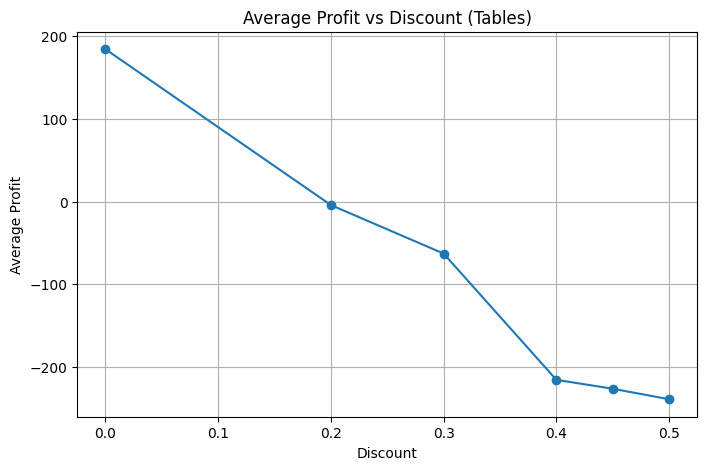

In [11]:
import matplotlib.pyplot as plt

table_profit = df[df["Sub-Category"]=="Tables"].groupby("Discount")["Profit"].mean()

plt.figure(figsize=(8,5))
plt.plot(table_profit.index, table_profit.values, marker='o')
plt.title("Average Profit vs Discount (Tables)")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.grid(True)
plt.show()

In [12]:
df[df["Sub-Category"]=="Tables"].groupby("Region")["Profit"].sum().sort_values()

,Profit
Region,
East,-11025.3801
South,-4623.0579
Central,-3559.6504
West,1482.6073


In [13]:
df[
    (df["Sub-Category"] == "Tables") &
    (df["Region"] == "East")
].groupby("State")["Profit"].sum().sort_values()

,Profit
State,
New York,-4535.6408
Ohio,-2715.3345
Pennsylvania,-2588.7538
Massachusetts,-545.2947
Rhode Island,-230.1678
New Hampshire,-105.3164
Delaware,-85.8963
West Virginia,-76.9536
Maryland,-71.1170


In [14]:
df[
    (df["Sub-Category"]=="Tables") &
    (df["Region"]=="East")
].groupby("State")[["Discount","Profit"]].mean().sort_values(by="Profit")

,Discount,Profit
State,,
Pennsylvania,0.4,-172.583587
Ohio,0.4,-169.708406
New York,0.4,-161.987171
New Hampshire,0.3,-105.316400
Massachusetts,0.3,-77.899243
West Virginia,0.3,-76.953600
Rhode Island,0.3,-57.541950
Delaware,0.3,-42.948150
Maryland,0.3,-35.558500


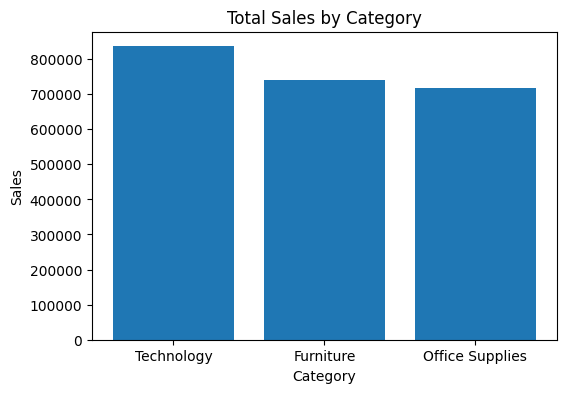

In [15]:
sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(sales.index, sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

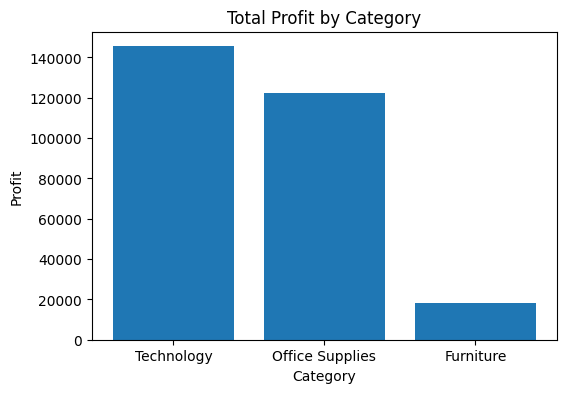

In [16]:
profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(profit.index, profit.values)
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

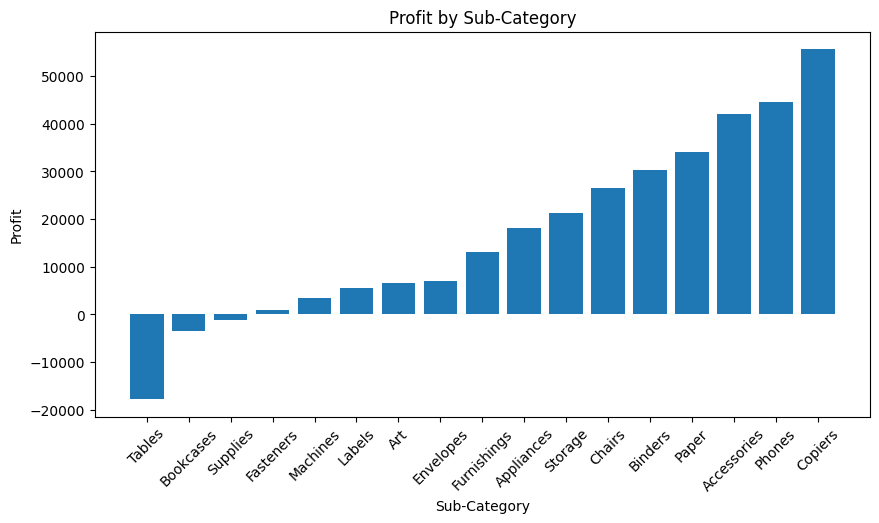

In [17]:
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(10,5))
plt.bar(sub_profit.index, sub_profit.values)
plt.xticks(rotation=45)
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.show()

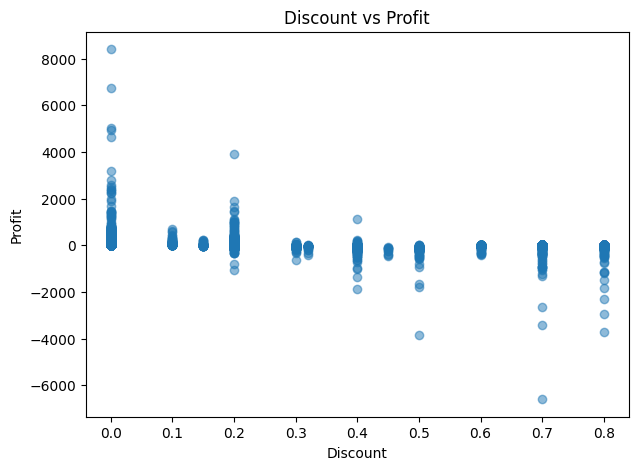

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

We started by understanding the business problem, then explored the dataset by checking its shape, data types, missing values, and duplicate records. After cleaning the data, we analyzed sales and profit across different categories and found that Technology generated the highest sales and profits, while Furniture, despite having high sales, contributed very little profit. To identify the reason, we drilled down into Furniture and discovered that Tables were the biggest loss-making sub-category, followed by Bookcases. We then investigated whether discounts were responsible and found that as discounts increased, the average profit for Tables decreased significantly. Further drill-down analysis showed that the East region contributed the highest losses, with New York, Ohio, and Pennsylvania being the major loss-making states. We also observed that these states had an average discount of 40%, compared to 30% in the remaining states, supporting our hypothesis that higher discounts are associated with lower profitability. Finally, we created four professional visualizations: Sales by Category, Profit by Category, Profit by Sub-Category, and Discount vs Profit, which clearly communicated these insights. At this stage, we have a strong business story backed by data and visualizations.

In [19]:
df.to_csv("Superstore_Cleaned.csv", index=False)

In [20]:
from google.colab import files
files.download("Superstore_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import sqlite3

In [2]:
conn = sqlite3.connect("superstore.db")

In [7]:
df.to_sql(
    "superstore",
    conn,
    if_exists="replace",
    index=False
)

9977

In [10]:
query = """
SELECT Category, Sales, Profit
FROM superstore
LIMIT 10;
"""

pd.read_sql(query, conn)

,Category,Sales,Profit
0,Furniture,261.9600,41.9136
1,Furniture,731.9400,219.5820
2,Office Supplies,14.6200,6.8714
3,Furniture,957.5775,-383.0310
4,Office Supplies,22.3680,2.5164
5,Furniture,48.8600,14.1694
6,Office Supplies,7.2800,1.9656
7,Technology,907.1520,90.7152
8,Office Supplies,18.5040,5.7825
9,Office Supplies,114.9000,34.4700


In [13]:
query = """
SELECT Category, Sales, Profit
FROM superstore
WHERE Profit < 0;
"""

pd.read_sql(query, conn)

,Category,Sales,Profit
0,Furniture,957.5775,-383.0310
1,Office Supplies,68.8100,-123.8580
2,Office Supplies,2.5440,-3.8160
3,Furniture,71.3720,-1.0196
4,Furniture,3083.4300,-1665.0522
...,...,...,...
1864,Office Supplies,22.3860,-35.8176
1865,Office Supplies,5.7420,-4.5936
1866,Furniture,683.3320,-40.1960
1867,Furniture,71.0880,-1.7772


In [14]:
pd.read_sql("""
SELECT SUM(Profit) AS Total_Profit
FROM superstore;
""", conn)

,Total_Profit
0,286241.4226


In [15]:
pd.read_sql("""
SELECT AVG(Discount) AS Average_Discount
FROM superstore;
""", conn)

,Average_Discount
0,0.156278


In [16]:
pd.read_sql("""
SELECT COUNT(*) AS Total_Orders
FROM superstore;
""", conn)

,Total_Orders
0,9977


In [17]:
pd.read_sql("""
SELECT Category,
       SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Category
ORDER BY Total_Sales DESC;
""", conn)

,Category,Total_Sales
0,Technology,836154.0330
1,Furniture,741306.3133
2,Office Supplies,718735.2440


In [18]:
pd.read_sql("""
SELECT Category,
       SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC;
""", conn)

,Category,Total_Profit
0,Technology,145454.9481
1,Office Supplies,122364.6608
2,Furniture,18421.8137


In [19]:
pd.read_sql("""
SELECT "Sub-Category",
       SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY "Sub-Category"
ORDER BY Total_Profit ASC;
""", conn)

,Sub-Category,Total_Profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995
3,Fasteners,949.5182
4,Machines,3384.7569
5,Labels,5526.3820
6,Art,6524.6118
7,Envelopes,6964.1767
8,Furnishings,13052.7230
9,Appliances,18138.0054


In [20]:
pd.read_sql("""
SELECT Region,
       SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Region
ORDER BY Total_Sales DESC;
""", conn)

,Region,Total_Sales
0,West,725255.6365
1,East,678435.1960
2,Central,500782.8528
3,South,391721.9050


In [21]:
pd.read_sql("""
SELECT Region,
       SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC;
""", conn)

,Region,Total_Profit
0,West,108329.8079
1,East,91506.3092
2,South,46749.4303
3,Central,39655.8752


In [22]:
pd.read_sql("""
SELECT State,
       SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY State
ORDER BY Total_Sales DESC
LIMIT 10;
""", conn)

,State,Total_Sales
0,California,457576.2715
1,New York,310827.1510
2,Texas,170124.5418
3,Washington,138560.8100
4,Pennsylvania,116496.3620
5,Florida,89473.7080
6,Illinois,80162.5370
7,Ohio,77976.7640
8,Michigan,75879.6440
9,Virginia,70636.7200


In [23]:
pd.read_sql("""
SELECT *
FROM superstore
WHERE Profit < 0;
""", conn)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
1,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,68.8100,5,0.80,-123.8580
2,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,2.5440,3,0.80,-3.8160
3,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.3720,2,0.30,-1.0196
4,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,Standard Class,Corporate,United States,Bryan,Texas,77803,Central,Office Supplies,Binders,22.3860,7,0.80,-35.8176
1865,Standard Class,Home Office,United States,Akron,Ohio,44312,East,Office Supplies,Binders,5.7420,3,0.70,-4.5936
1866,Standard Class,Consumer,United States,San Bernardino,California,92404,West,Furniture,Bookcases,683.3320,4,0.15,-40.1960
1867,Second Class,Corporate,United States,Los Angeles,California,90049,West,Furniture,Tables,71.0880,2,0.20,-1.7772


In [24]:
pd.read_sql("""
SELECT *
FROM superstore
WHERE Discount > 0.20;
""", conn)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
1,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,68.8100,5,0.80,-123.8580
2,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,2.5440,3,0.80,-3.8160
3,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.3720,2,0.30,-1.0196
4,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1386,Standard Class,Consumer,United States,Carrollton,Texas,75007,Central,Furniture,Furnishings,25.1280,3,0.60,-6.9102
1387,Standard Class,Corporate,United States,Bryan,Texas,77803,Central,Furniture,Chairs,528.4300,5,0.30,-143.4310
1388,Standard Class,Corporate,United States,Bryan,Texas,77803,Central,Office Supplies,Binders,22.3860,7,0.80,-35.8176
1389,Standard Class,Home Office,United States,Akron,Ohio,44312,East,Office Supplies,Binders,5.7420,3,0.70,-4.5936


In [25]:
pd.read_sql("""
SELECT *
FROM superstore
WHERE Region = 'East'
AND Profit < 0;
""", conn)
pd.read_sql("""
SELECT Category,
       AVG(Profit) AS Average_Profit
FROM superstore
GROUP BY Category
ORDER BY Average_Profit DESC;
""", conn)

,Category,Average_Profit
0,Technology,78.752002
1,Office Supplies,20.353403
2,Furniture,8.697740


In [26]:
pd.read_sql("""
SELECT "Product Name",
       SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY "Product Name"
ORDER BY Total_Profit DESC
LIMIT 10;
""", conn)

,"""Product Name""",Total_Profit
0,Product Name,286241.4226
